In [101]:
import scanpy as sc
import squidpy as sq
import tangram as tg
import numpy as np

In [113]:
adata_st = sq.datasets.visium_fluo_adata_crop()
adata_st = adata_st[
    adata_st.obs.cluster.isin([f"Cortex_{i}" for i in np.arange(1, 5)])
].copy()
img = sq.datasets.visium_fluo_image_crop()

adata_sc = sq.datasets.sc_mouse_cortex()

  0%|          | 0.00/3.03G [00:00<?, ?B/s]

In [138]:
adata_sc

AnnData object with n_obs × n_vars = 21697 × 36826
    obs: 'sample_name', 'organism', 'donor_sex', 'cell_class', 'cell_subclass', 'cell_cluster', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_class_colors', 'cell_subclass_colors', 'hvg', 'neighbors', 'pca', 'umap', 'training_genes', 'overlap_genes'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [140]:
ad_sc

AnnData object with n_obs × n_vars = 29878 × 26651
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'cluster_alias', 'class'
    var: 'n_cells'
    uns: 'normalization', 'parent', 'parent_layer', 'parent_rows', 'log1p', 'training_genes', 'overlap_genes'

In [139]:
adata_st

AnnData object with n_obs × n_vars = 324 × 16174
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster', 'uniform_density', 'rna_count_based_density'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'sparsity'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap', 'training_genes', 'overlap_genes'
    obsm: 'X_pca', 'X_umap', 'spatial', 'tangram_ct_pred'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [141]:
ad_sp

AnnData object with n_obs × n_vars = 25660 × 18751
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'sample_id', 'n_genes', 'leiden', 'treatment', 'barcode', 'region_annotation', 'leiden_0.5', 'leiden_0.75', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'PIG_score', 'OLIG_score', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 're_annotation_regions', 'uniform_density', 'rna_count_based_density'
    var: 'n_cells'
    uns: 'dendrogram_treatment', 'leiden', 'leiden_0.1_colors', 'leiden_0.2_colors', 'leiden_0.3_colors', 'leiden_0.5_colors', 'leiden_0.75_colors', 'leiden_1.5_colors', 'leiden_1_colors', 'leiden_2.5_colors', 'leiden_2_colors', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'region_annotation_colors', 'sample_id_colors', 'spatial', 'spatial_metadata_per_sample', 'umap', 'training_genes', 'overlap_genes'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities

In [117]:
adata_sc.X.max()

13.157556

In [118]:
adata_st.X.max()

6.464124

In [119]:
tg.pp_adatas(adata_sc, adata_st)


INFO:root:14785 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:14785 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [120]:

ad_map = tg.map_cells_to_space(adata_sc, adata_st,
  #  mode="cells",
    mode="clusters",
    cluster_label='cell_subclass',  # .obs field w cell types
    density_prior='rna_count_based',
    num_epochs=500,
    # device="cuda:0",
    device='cpu',
)

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 14785 genes and rna_count_based density_prior in clusters mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.438, KL reg: 0.060
Score: 0.482, KL reg: 0.000
Score: 0.483, KL reg: 0.000
Score: 0.483, KL reg: 0.000
Score: 0.483, KL reg: 0.000


INFO:root:Saving results..


INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


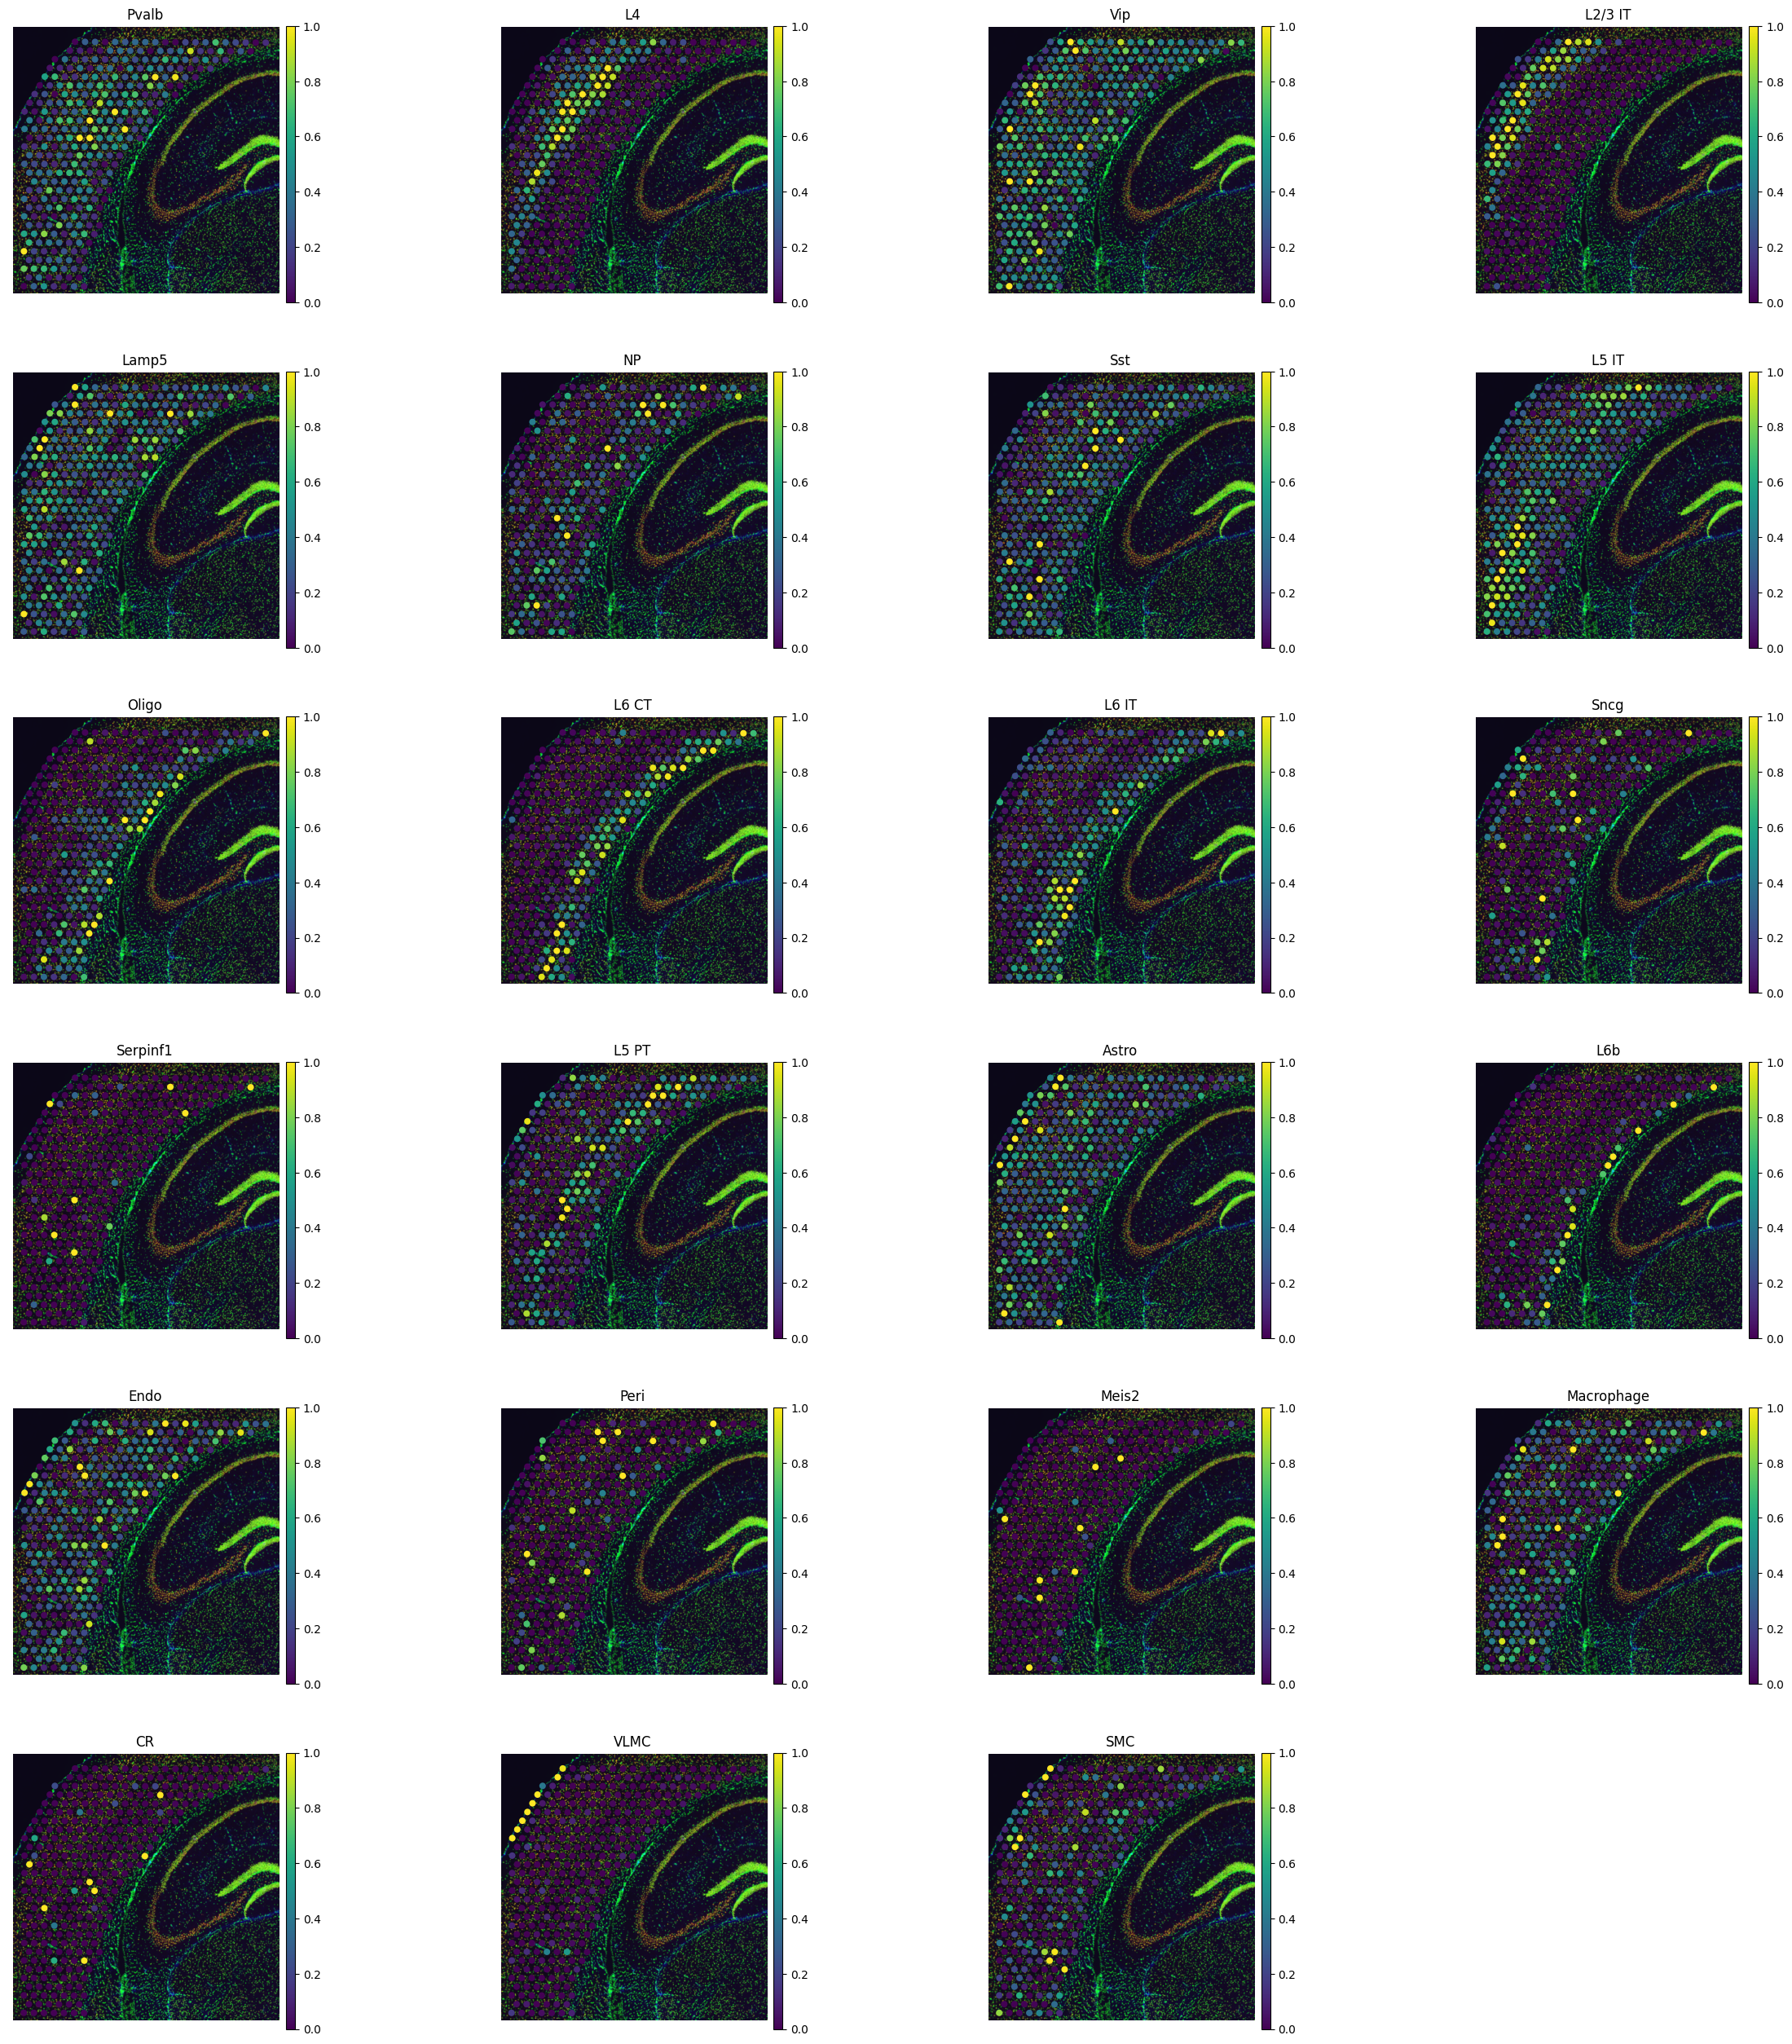

In [121]:
tg.project_cell_annotations(ad_map, adata_st, annotation="cell_subclass")
annotation_list = list(pd.unique(adata_sc.obs['cell_subclass']))
tg.plot_cell_annotation_sc(adata_st, annotation_list,perc=0.02)

In [127]:
ad_sc = sc.read_h5ad('/Users/christoffer/work/karolinska/development/data/abc_atlas/expression_matrices/WMB-10Xv2/20230630/WMB-10Xv2-MB-raw_with_meta.h5ad')
ad_sp = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

In [128]:
sc.pp.normalize_total(ad_sc, target_sum=1e4)
sc.pp.normalize_total(ad_sp, target_sum=1e4)

In [129]:
ad_sc.var = ad_sc.var.set_index('gene_symbol')

In [131]:
sc.pp.log1p(ad_sp)
sc.pp.log1p(ad_sc)

In [132]:
print(ad_sp.X.max())
print(ad_sc.X.max())

4.0463266
7.857326


In [133]:
tg.pp_adatas(ad_sc, ad_sp)


INFO:root:17249 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:17255 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [134]:
ad_sc

AnnData object with n_obs × n_vars = 29878 × 26651
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'cluster_alias', 'class'
    var: 'n_cells'
    uns: 'normalization', 'parent', 'parent_layer', 'parent_rows', 'log1p', 'training_genes', 'overlap_genes'

In [ ]:

ad_map = tg.map_cells_to_space(ad_sc, ad_sp,
  #  mode="cells",
    mode="clusters",
    cluster_label='class',  # .obs field w cell types
    density_prior='rna_count_based',
    num_epochs=500,
    # device="cuda:0",
    device='cpu',
)

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 17249 genes and rna_count_based density_prior in clusters mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.387, KL reg: 0.125


In [106]:
ad_map = tg.map_cells_to_space(
        ad_sc, 
        ad_sp,   
        num_epochs=300,
        mode='clusters',
        cluster_label='class',
)

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 17249 genes and rna_count_based density_prior in clusters mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.367, KL reg: 0.117
Score: 0.435, KL reg: 0.000
Score: 0.436, KL reg: 0.000


INFO:root:Saving results..


In [107]:
import pandas as pd

In [108]:
ad_sp.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,sample,sample_id,n_genes,leiden,treatment,...,leiden_2,leiden_2.5,PIG_score,OLIG_score,leiden_0.1,leiden_0.2,leiden_0.3,re_annotation_regions,uniform_density,rna_count_based_density
AAACAAGTATCTCCCA-1-P24215_301,1,50,102,28217,34029,P24215_301,P24215_301,5333,6,BRICHOS,...,11,35,0.093254,0.006935,0,5,5,Olfactory areas,0.000039,0.000039
AAACAGAGCGACTCCT-1-P24215_301,1,14,94,10018,31732,P24215_301,P24215_301,3317,1,BRICHOS,...,17,7,0.374221,1.611454,3,2,3,Hypothalamus,0.000039,0.000039
AAACCGGGTAGGTACC-1-P24215_301,1,42,28,24142,12539,P24215_301,P24215_301,4982,0,BRICHOS,...,1,14,0.229887,0.858781,0,1,1,Supragranualar layers,0.000039,0.000039
AAACCGTTCGTCCAGG-1-P24215_301,1,52,42,29202,16598,P24215_301,P24215_301,6046,0,BRICHOS,...,0,11,0.012875,0.548931,0,3,2,Infragranular layers,0.000039,0.000039
AAACCTCATGAAGTTG-1-P24215_301,1,37,19,21611,9928,P24215_301,P24215_301,6179,0,BRICHOS,...,1,14,0.076070,0.235175,0,1,1,Supragranualar layers,0.000039,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTCAGTGTGCTAC-1-P28052_203,1,24,64,15524,23040,P28052_203,P28052_203,7233,4,PBS,...,41,37,0.145172,1.043804,1,0,0,Caudoputamen,0.000039,0.000039
TTGTTGTGTGTCAAGA-1-P28052_203,1,31,77,19072,26813,P28052_203,P28052_203,7315,4,PBS,...,41,37,0.225508,0.990587,1,0,0,Caudoputamen,0.000039,0.000039
TTGTTTCATTAGTCTA-1-P28052_203,1,60,30,33717,13124,P28052_203,P28052_203,6504,1,PBS,...,5,15,0.168308,0.581865,3,2,3,Hypothalamus,0.000039,0.000039
TTGTTTCCATACAACT-1-P28052_203,1,45,27,26128,12265,P28052_203,P28052_203,5322,1,PBS,...,17,27,0.307190,0.876207,3,2,3,Hypothalamus,0.000039,0.000039


In [109]:
annotation_list

['01 IT-ET Glut',
 '30 Astro-Epen',
 '20 MB GABA',
 '19 MB Glut',
 '02 NP-CT-L6b Glut',
 '06 CTX-CGE GABA',
 '14 HY Glut',
 '31 OPC-Oligo',
 '05 OB-IMN GABA',
 '07 CTX-MGE GABA',
 '18 TH Glut',
 '08 CNU-MGE GABA',
 '04 DG-IMN Glut',
 '26 P GABA',
 '34 Immune',
 '33 Vascular',
 '11 CNU-HYa GABA',
 '03 OB-CR Glut',
 '09 CNU-LGE GABA',
 '12 HY GABA',
 '16 HY MM Glut',
 '13 CNU-HYa Glut',
 '10 LSX GABA',
 '23 P Glut',
 '24 MY Glut',
 '25 Pineal Glut']

In [110]:
tg.project_cell_annotations(ad_map, ad_sp, annotation='class')
annotation_list = list(pd.unique(ad_sc.obs['class']))

INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


In [111]:
import numpy as np
import scanpy as sc

def plot_cell_annotation_sc_with_library(
    adata_sp,
    annotation_list,
    *,
    library_id=None,        # e.g. "P24215_101"
    library_col=None,       # e.g. "sample_id" if each cell has its library label
    x="x",
    y="y",
    spot_size=None,
    scale_factor=None,
    perc=0,
    alpha_img=1.0,
    bw=False,
    ax=None,
):
    """
    Drop-in replacement for tg.plot_cell_annotation_sc with support for multi-library AnnData.
    """

    # Clean previous columns
    adata_sp.obs.drop(annotation_list, inplace=True, errors="ignore", axis=1)

    # Build obs columns from obsm["tangram_ct_pred"]
    if "tangram_ct_pred" not in adata_sp.obsm:
        raise KeyError("adata_sp.obsm['tangram_ct_pred'] not found.")
    df = adata_sp.obsm["tangram_ct_pred"][annotation_list]
    # --- construct_obs_plot(df, adata_sp, perc=perc) inline ---
    # keep top-`perc` percentile if desired (perc=0 keeps all)
    if perc and perc > 0:
        thr = np.nanpercentile(df.values, 100 - perc, axis=0)
        df = df.where(df.ge(thr, axis=1), other=np.nan)
    for col in df.columns:
        adata_sp.obs[col] = df[col].values

    # Decide plotting path
    has_uns_spatial = "spatial" in adata_sp.uns and isinstance(adata_sp.uns["spatial"], dict)

    # Case A: Visium-style with .uns['spatial'] present -> must specify library
    if has_uns_spatial:
        if library_id is None:
            # Try to infer from a per-cell column if provided
            if library_col is not None and library_col in adata_sp.obs:
                vals = adata_sp.obs[library_col].astype(str).unique().tolist()
                if len(vals) == 1:
                    library_id = vals[0]
                else:
                    raise ValueError(
                        "Found multiple libraries in `.uns['spatial']` and multiple values in "
                        f"obs['{library_col}'] ({vals}). Please pass library_id='...'. "
                        f"Options in uns['spatial']: {list(adata_sp.uns['spatial'].keys())}"
                    )
            else:
                raise ValueError(
                    "Found multiple libraries in `.uns['spatial']`. Please pass library_id='...'. "
                    f"Options: {list(adata_sp.uns['spatial'].keys())}"
                )

        # Rules from original Tangram function
        if spot_size is not None and scale_factor is not None:
            raise ValueError("Spot Size and Scale Factor should be None when ad_sp.uns['spatial'] exists")

        sc.pl.spatial(
            adata_sp,
            color=annotation_list,
            library_id=library_id,    # <-- the missing piece
            cmap="viridis",
            show=False,
            frameon=False,
            spot_size=spot_size,
            scale_factor=scale_factor,
            alpha_img=alpha_img,
            bw=bw,
            ax=ax,
        )

    # Case B: No Visium mapping in .uns -> fall back to coordinates
    else:
        # If there are no spatial coords in .obsm, build them from obs[x], obs[y]
        if "spatial" not in adata_sp.obsm:
            if (x not in adata_sp.obs) or (y not in adata_sp.obs):
                raise KeyError(
                    "No .uns['spatial'] and .obsm['spatial'] missing. "
                    f"Provide obs columns x='{x}' and y='{y}' or supply a Visium .uns['spatial']."
                )
            coords = np.column_stack([adata_sp.obs[x].to_numpy(), adata_sp.obs[y].to_numpy()])
            adata_sp.obsm["spatial"] = coords.astype(float)

        if spot_size is None and scale_factor is None:
            raise ValueError(
                "Spot Size and Scale Factor cannot be None when ad_sp.uns['spatial'] does not exist"
            )

        sc.pl.spatial(
            adata_sp,
            color=annotation_list,
            cmap="viridis",
            show=False,
            frameon=False,
            spot_size=spot_size,
            scale_factor=scale_factor,
            alpha_img=alpha_img,
            bw=bw,
            ax=ax,
        )

    # cleanup
    adata_sp.obs.drop(annotation_list, inplace=True, errors="ignore", axis=1)

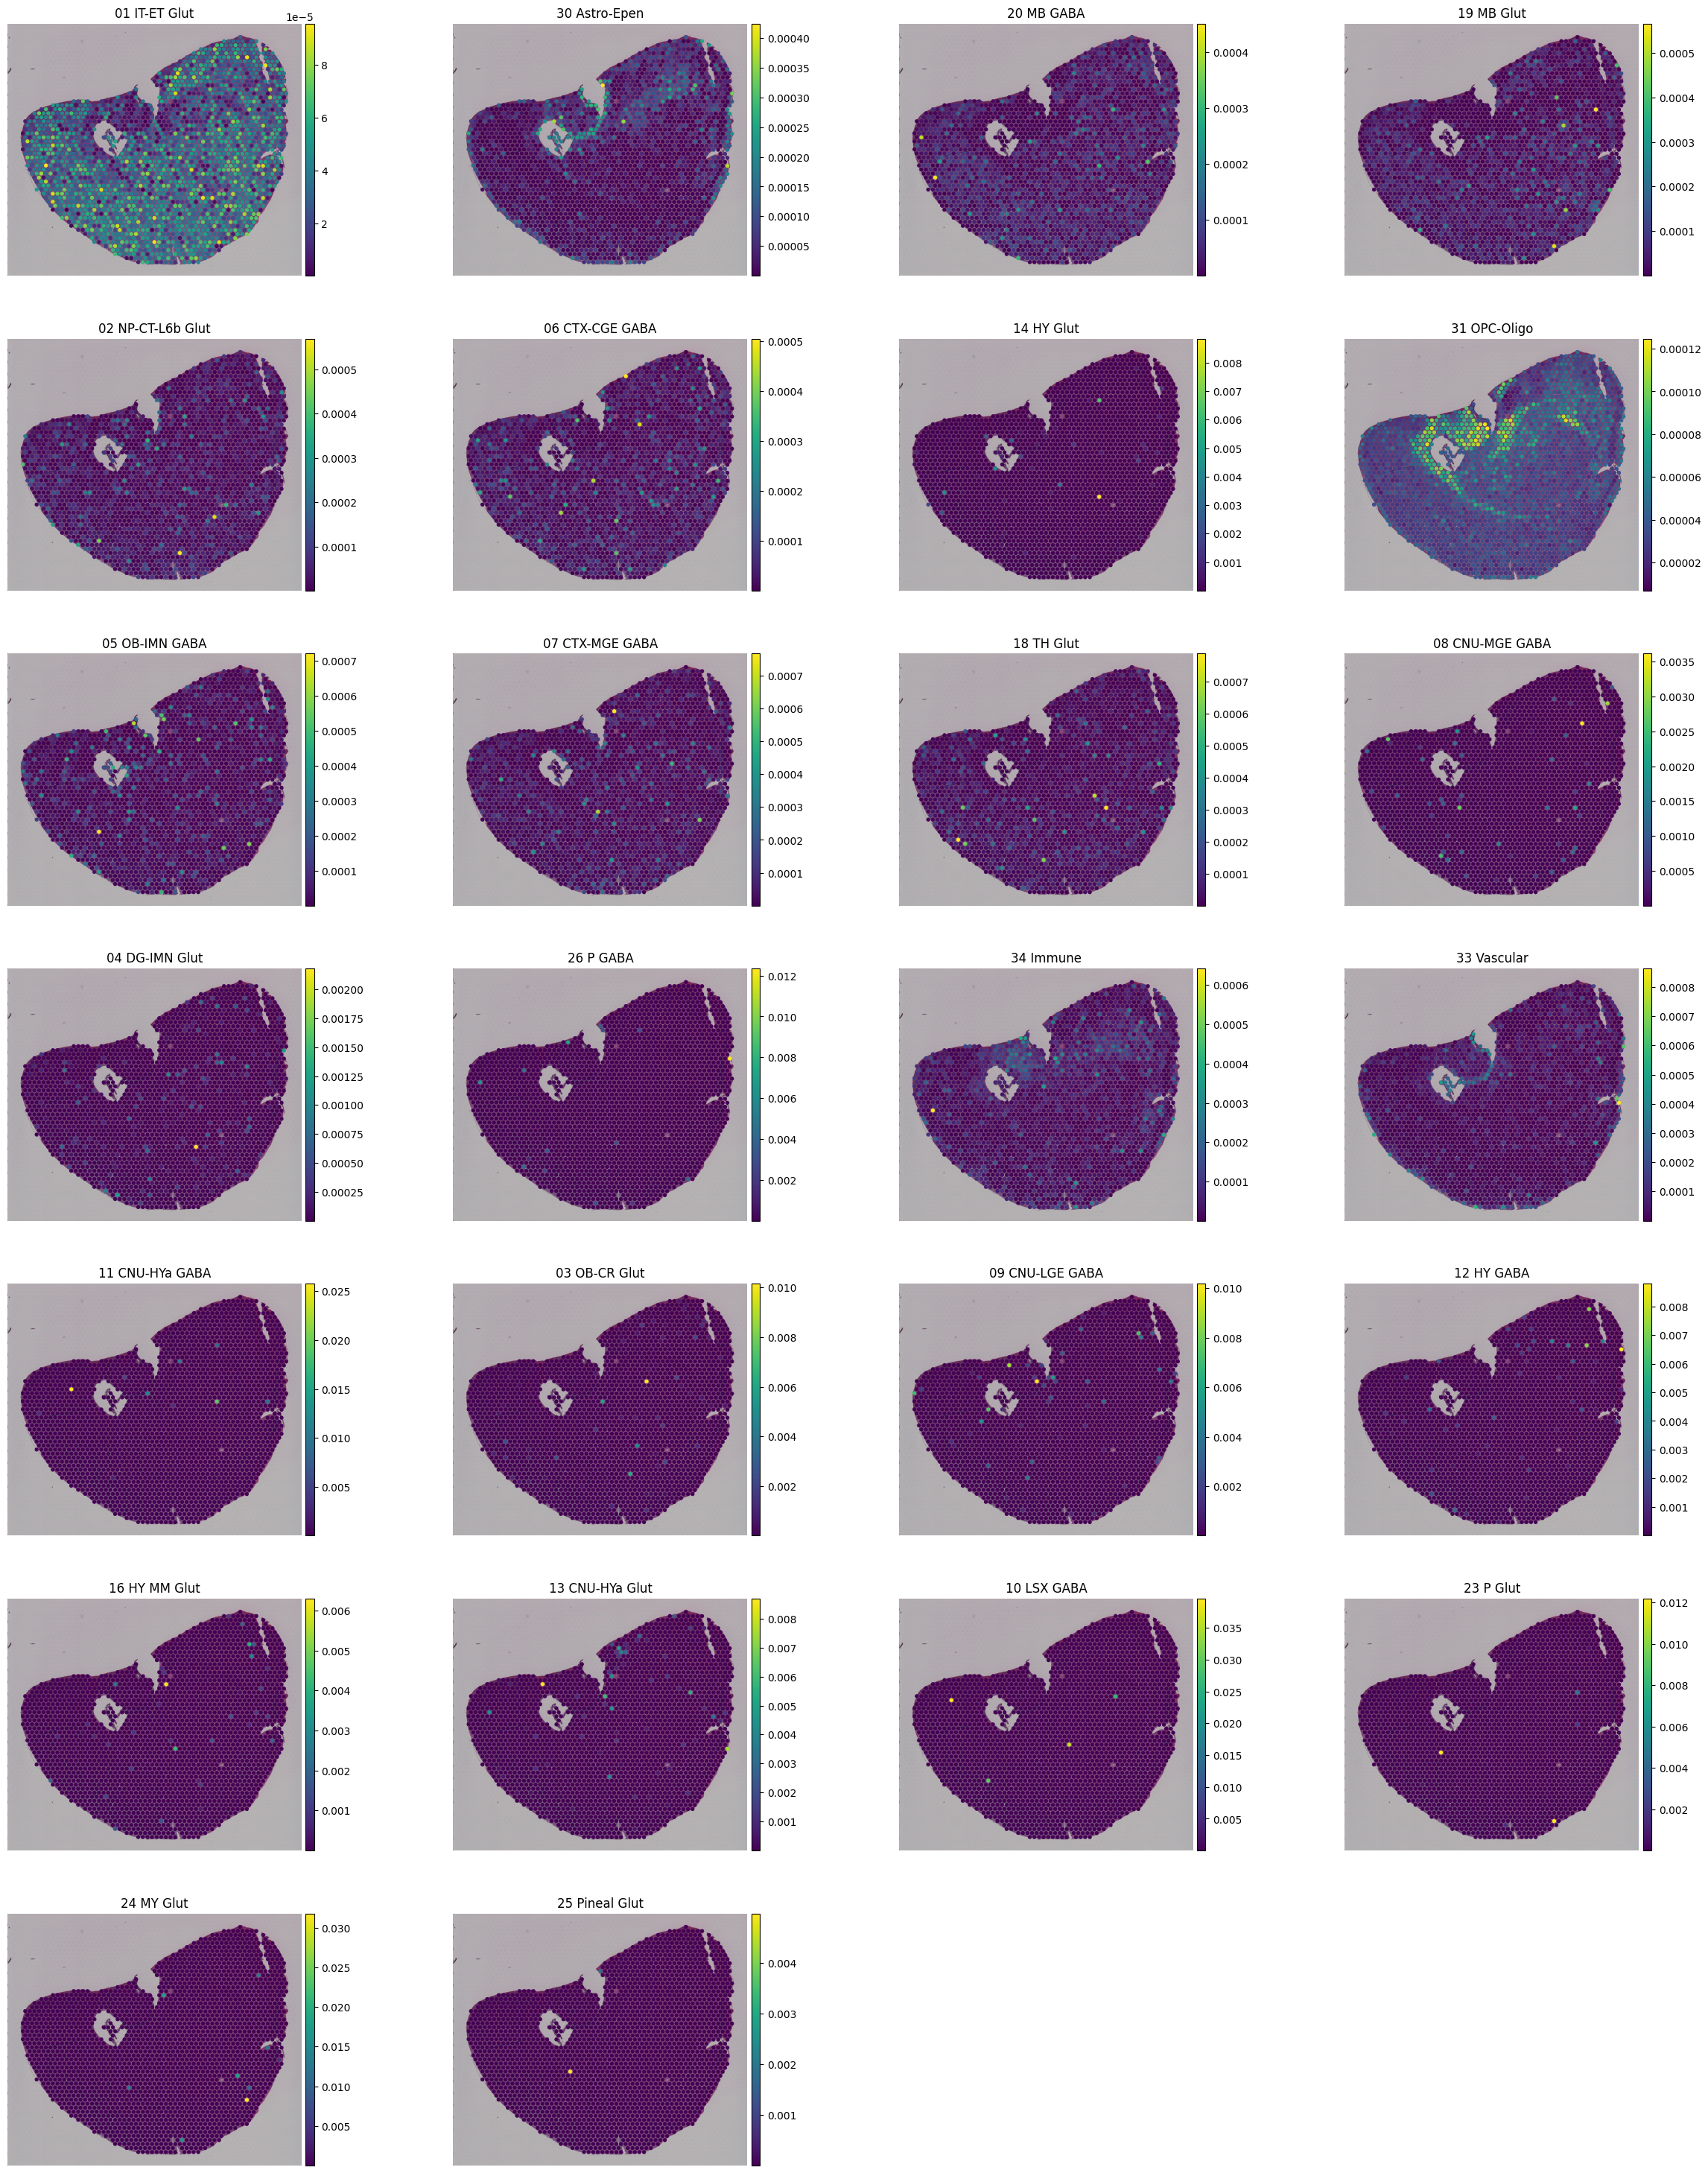

In [112]:
plot_cell_annotation_sc_with_library(
    ad_sp[ad_sp.obs.sample_id == "P24215_301"].copy(),
    annotation_list,
    library_id="P24215_301",   # <- required when multiple libraries exist
    spot_size=500
)